Preprocessing: Spike cleaning and peak-to-peak thresholding available. \
Analysis: PCA for keypoint data and for ECoG data available. \
Plotting: Spectrogram, morlet scalogram, spatial data plotting available. \

Will add: velocity data for keypoints, RRR function

In [ ]:
!git clone https://github.com/mserhat1/NMA_Project.git
import sys
sys.path.append('/content/NMA_Project')

In [ ]:
%cd NMA_Project
!pip install -r requirements.txt

Choose subject and session

In [ ]:
from functions.data import get_datafile

sbj = 10
session = 3

nwbfile = get_datafile(sbj=sbj, session=session)

Extract spatial data

In [4]:
from functions.data import extract_spatial_data

spatial_data = extract_spatial_data(nwbfile)

Plot spatial data

In [ ]:
from functions.plotting import plot_spatial_data

keypoints = ['R_Wrist', 'L_Wrist', 'R_Shoulder', 'L_Shoulder', 'R_Elbow', 'L_Elbow', 'R_Ear', 'L_Ear', 'Nose']
time_window = 'all'

# If time_window is 'all', it shows you the entire data.
# If you want a specific time window, uncomment the line below and adjust the interval.
#time_window = (55000, 56500)

plot_spatial_data(spatial_data, keypoints, time_window=time_window, plot_histogram=True)

Apply PCA over time-series data from keypoints

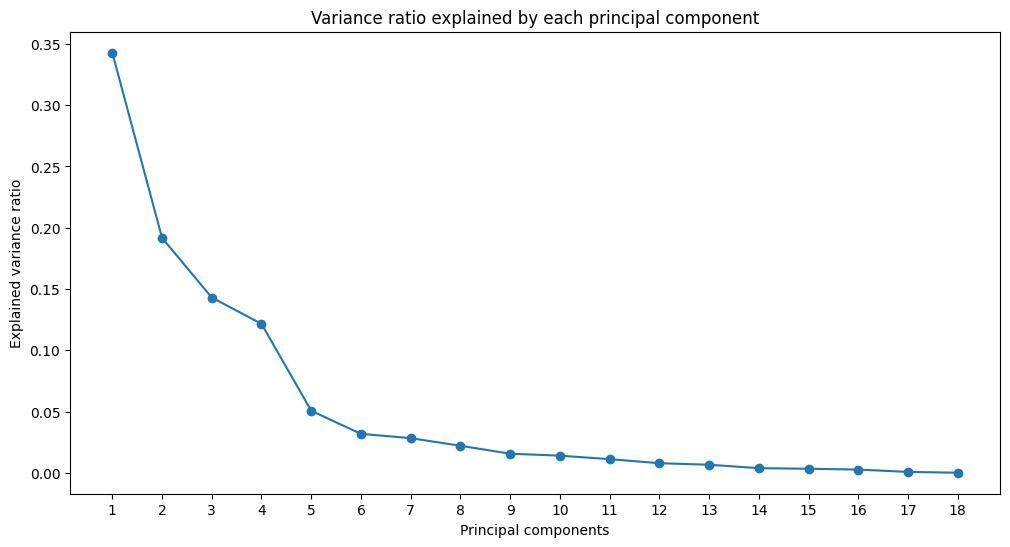

In [5]:
from functions.analysis import keypoints_pca

pc_data = keypoints_pca(spatial_data, time_window=(55000, 56500), plot=True)

In [6]:
# Seems like 4 PC's is a good choice in this case.
chosen_pcs = 4

kp_data = pc_data['kp_data']
pcs = pc_data['components'] # (n_components, n_features)
top_pcs = pcs[:chosen_pcs, :]

print(top_pcs.shape, kp_data.shape)
projected_data = kp_data @ top_pcs.T

print(projected_data.shape) # (n_samples, n_components)

(4, 18) (45000, 18)
(45000, 4)


Extract neural data

In [40]:
# specify parameters
channel = 'all'
time_window = (55000, 56500)

ecog_data = extract_neural_data(nwbfile, channel=channel, time_window=time_window)

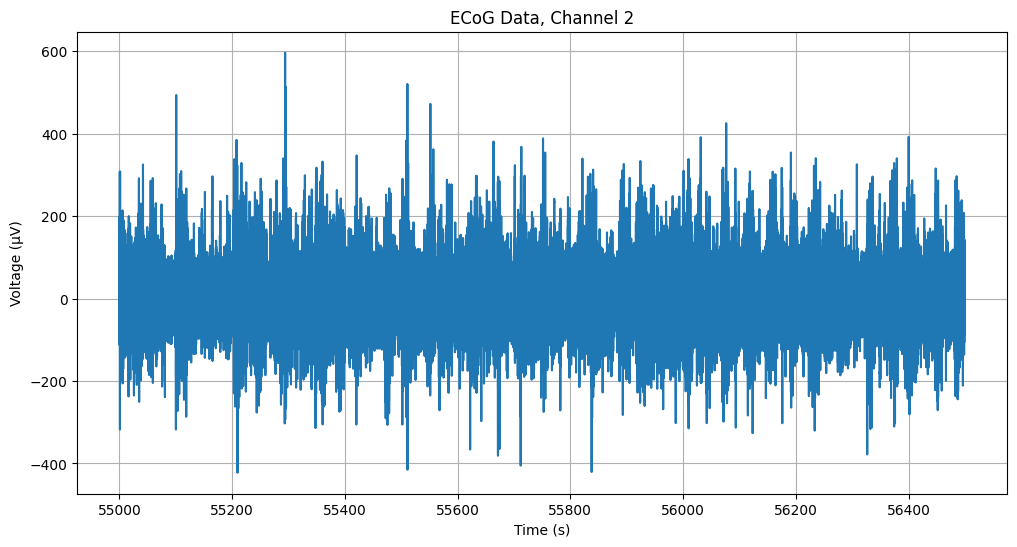

In [38]:
from functions.plotting_new import plot_signal

# don't use the whole time window for plotting, it will take forever.
plot_signal(ecog_data)

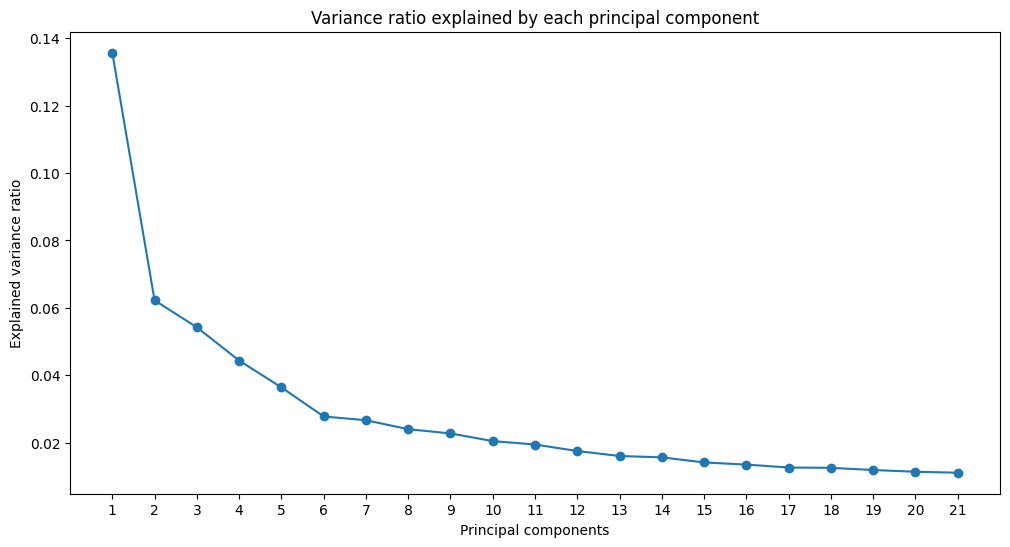

In [56]:
from functions.analysis import ecog_pca

pca = ecog_pca(ecog_data, time_window=(55000, 56500), n_components=0.60, plot=True)

Apply further preprocessing

In [ ]:
from functions.preprocessing import spike_cleaning

clean_data = spike_cleaning(ecog_data, mode='interp')

In [ ]:
from functions.plotting_new import plot_spectrogram, plot_morlet
# NOTE: These functions work only for single channel ecog_data, for more channels they will give an error!

# computes spectrogram for each time epoch around the event, then averages across epochs
# specify parameters
plot_spectrogram(clean_data, lower_freq=70, upper_freq=150, nperseg=256)

# complex morlet wavelet transform, baseline corrected with z-score (per epoch),
# I will include the option to apply baseline correction after averaging the
# transforms as well.
# specify parameters
plot_morlet(clean_data, lower_freq=1, upper_freq=60, B=4, C=10)